<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20CIFAR-10%20Denoiser/CIFAR-10%20Denoiser%20-%2001_backprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — CNN regime 1 (CIFAR-10 Denoiser) · Backprop (Adam + MSE)
Denoise a CIFAR-10 image (input = clean + N(0,0.1^2) noise, target = clean) (P≈1.01M ConvAE); loss = MSE, metrics = PSNR (dB) + SSIM.

## Step 0 — Setup

In [1]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config

In [2]:
METHOD = 'backprop'
LR_BP = 1e-3
METHOD_CFG = dict(LR_BP=LR_BP)


# =============================== CONFIG (shared across the 5 methods) ===============================
# CNN autoencoder (~1.01M) on CIFAR-10. Same P as the MNIST §6/§7/§8 runs -> cos sweep comparable.
CONV_C, LATENT = 32, 118          # channels / bottleneck; build cell prints exact P (target ~1.01M)
CORRUPT_SIGMA  = 0.1            # 0.0 = autoencoder, >0 = denoiser (input = clean + N(0,sigma^2) noise)
DRIVE_SUBDIR   = 'Section7_r1_cifar10_denoiser'
TIME_BUDGET_HOURS = 2.0
BATCH             = 128
SEED              = 0
EVAL_N, EVAL_BATCH = 4096, 1024
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE = True


SMOKE = False
if SMOKE:                                     # ~20-40 s CPU check
    CONV_C, LATENT = 8, 16
    TIME_BUDGET_HOURS = 30/3600
    LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 1, 2, 999, 1
    EVAL_N, EVAL_BATCH, USE_DRIVE = 512, 512, False
# ===================================================================================================

## Step 1 — Storage (Drive) + paths

In [3]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Mounted at /content/drive
storing under: /content/drive/MyDrive/Section7_r1_cifar10_denoiser


## Step 2 — Model (CNN autoencoder)

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    """Conv encoder -> dense latent bottleneck -> Upsample+Conv decoder -> 3x32x32 logits.
    No BatchNorm (vmap-clean); Upsample+Conv instead of ConvTranspose (vmap-safe)."""
    def __init__(self, conv_c=32, latent=118):
        super().__init__()
        c2 = 2 * conv_c
        self.enc = nn.Sequential(
            nn.Conv2d(3, conv_c, 3, stride=2, padding=1), nn.ReLU(),   # 32 -> 16
            nn.Conv2d(conv_c, c2, 3, stride=2, padding=1), nn.ReLU(),  # 16 -> 8
        )
        self._c2 = c2
        self.fc1 = nn.Linear(c2 * 8 * 8, latent)
        self.fc2 = nn.Linear(latent, c2 * 8 * 8)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),               # 8 -> 16
            nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),               # 16 -> 32
            nn.Conv2d(conv_c, 3, 3, padding=1),
        )
    def forward(self, x):
        h = self.enc(x)
        b = h.shape[0]
        z = self.fc1(h.reshape(b, -1))
        h2 = self.fc2(z).reshape(b, self._c2, 8, 8)
        return self.dec(h2)                                            # (B,3,32,32) logits

## Step 3 — Data (CIFAR-10)

In [5]:
import torchvision
CIFAR_ROOT = globals().get('CIFAR_ROOT', './data')          # smoke can override to a local copy
CIFAR_DL   = globals().get('CIFAR_DOWNLOAD', True)
_tr = torchvision.datasets.CIFAR10(CIFAR_ROOT, train=True,  download=CIFAR_DL)
_te = torchvision.datasets.CIFAR10(CIFAR_ROOT, train=False, download=CIFAR_DL)
def _to_img(ds):                                            # (N,32,32,3) uint8 -> (N,3,32,32) float [0,1]
    a = torch.as_tensor(ds.data, dtype=torch.float32) / 255.0
    return a.permute(0, 3, 1, 2).contiguous().to(device)
Xtr = _to_img(_tr); Xte_all = _to_img(_te)
if SMOKE:
    Xtr, Xte_all = Xtr[:2000], Xte_all[:512]

def _corrupt(x):
    return x + CORRUPT_SIGMA * torch.randn_like(x) if CORRUPT_SIGMA > 0 else x

torch.manual_seed(SEED)                                     # reproducible eval corruption
Xte_tgt = Xte_all[:EVAL_N]
Xte_in  = _corrupt(Xte_tgt)

def fresh_batch(n):
    idx = torch.randint(0, Xtr.shape[0], (n,), device=device)
    xb = Xtr[idx]
    return _corrupt(xb), xb                                 # (input, clean target)
print(f'CIFAR-10 | train {tuple(Xtr.shape)} | test-eval {tuple(Xte_tgt.shape)} | corrupt sigma={CORRUPT_SIGMA}')

100%|██████████| 170M/170M [34:52<00:00, 81.5kB/s]


CIFAR-10 | train (50000, 3, 32, 32) | test-eval (4096, 3, 32, 32) | corrupt sigma=0.1


## Step 4 — Build + budget

In [6]:
torch.manual_seed(SEED)
model = ConvAE(CONV_C, LATENT).to(device)
P = sum(p.numel() for p in model.parameters())
Mstar = math.ceil((P + 1) / 3)
if METHOD.startswith('three_factor'):
    M = max(1, round(TARGET_COS**2 * (P + 1) / (1 - TARGET_COS**2)))
    got = (M / (M + P + 1))**0.5
    print(f'target cos = {TARGET_COS} -> M = {M:,} probes/step (actual cos = {got:.4f}); M*(cos=0.5) = {Mstar:,}')
else:
    M = 0
print(f'METHOD = {METHOD} | ConvAE P = {P:,} | conv_c={CONV_C} latent={LATENT}')
CFG = dict(METHOD=METHOD, SEED=SEED, CONV_C=CONV_C, LATENT=LATENT, BATCH=BATCH, CORRUPT_SIGMA=CORRUPT_SIGMA,
           TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)
if METHOD.startswith('three_factor'):
    CFG['M'] = M
assert P < 3_000_000, 'ConvAE too large for a from-scratch three-factor run (cost ~ P^2 at the clean budget).'

METHOD = backprop | ConvAE P = 1,009,593 | conv_c=32 latent=118


## Step 6 — Trainer

In [7]:
torch.manual_seed(SEED)
net = ConvAE(CONV_C, LATENT).to(device)
opt = torch.optim.Adam(net.parameters(), lr=LR_BP)
def forward_fn(x): return net(x)
def train_step():
    xb, yb = fresh_batch(BATCH)
    opt.zero_grad(); loss = F.mse_loss(torch.sigmoid(net(xb)), yb); loss.backward(); opt.step()
    return loss.item()
def ckpt_state():      return {'net': net.state_dict(), 'opt': opt.state_dict()}
def load_ckpt_state(d): net.load_state_dict(d['net']); opt.load_state_dict(d['opt'])

## Step 7 — Eval / checkpoint / live-plot

In [8]:
# metrics: MSE (loss), PSNR (dB), SSIM (structural similarity). SSIM is eval-only (base-model outputs -> no vmap needed).
def _gauss_window(ch, ks=7, sigma=1.5):
    c = torch.arange(ks, dtype=torch.float32, device=device) - (ks - 1) / 2
    g = torch.exp(-(c**2) / (2 * sigma**2)); g = g / g.sum()
    w = (g[:, None] * g[None, :])
    return w.expand(ch, 1, ks, ks).contiguous()
_SSIM_WIN = None
@torch.no_grad()
def _ssim(a, b):                                                       # a,b in [0,1], (B,3,H,W) -> mean SSIM
    global _SSIM_WIN
    if _SSIM_WIN is None: _SSIM_WIN = _gauss_window(a.shape[1])
    C1, C2 = 0.01**2, 0.03**2; ch = a.shape[1]; pad = _SSIM_WIN.shape[-1] // 2
    mu_a = F.conv2d(a, _SSIM_WIN, padding=pad, groups=ch); mu_b = F.conv2d(b, _SSIM_WIN, padding=pad, groups=ch)
    mu_a2, mu_b2, mu_ab = mu_a*mu_a, mu_b*mu_b, mu_a*mu_b
    va  = F.conv2d(a*a, _SSIM_WIN, padding=pad, groups=ch) - mu_a2
    vb  = F.conv2d(b*b, _SSIM_WIN, padding=pad, groups=ch) - mu_b2
    vab = F.conv2d(a*b, _SSIM_WIN, padding=pad, groups=ch) - mu_ab
    s = ((2*mu_ab + C1) * (2*vab + C2)) / ((mu_a2 + mu_b2 + C1) * (va + vb + C2))
    return s.mean().item()

@torch.no_grad()
def eval_metrics():
    mse_sum = 0.0; ssim_w = 0.0; ne = 0; nb = 0
    for i in range(0, Xte_tgt.shape[0], EVAL_BATCH):
        rec = torch.sigmoid(forward_fn(Xte_in[i:i+EVAL_BATCH])); tgt = Xte_tgt[i:i+EVAL_BATCH]
        mse_sum += F.mse_loss(rec, tgt, reduction='sum').item(); ne += tgt.numel()
        ssim_w += _ssim(rec, tgt) * tgt.shape[0]; nb += tgt.shape[0]
    mse = mse_sum / ne; psnr = 10.0 * math.log10(1.0 / max(mse, 1e-12)); ssim = ssim_w / nb
    return mse, psnr, ssim                                             # (MSE/pixel, PSNR dB, SSIM)

In [9]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [10]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]; tr=[l[3] for l in logs]; mse=[l[4] for l in logs]; psnr=[l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-', color='#999', label='train MSE'); ax[0].plot(hrs, mse, 'o-', color='#C62828', label='test MSE')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('MSE / pixel'); ax[0].set_title(f'{METHOD}: MSE vs time'); ax[0].legend()
    ax[1].plot(hrs, psnr, 'o-', color='#1F3864')
    ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]; print(f'[h={last[0]/3600:.2f}] step={last[1]:,} test_mse={last[4]:.5f} psnr={last[5]:.2f} ssim={last[6]:.3f}')

## Step 8 — Train (equal wall-clock, heartbeat) + save results

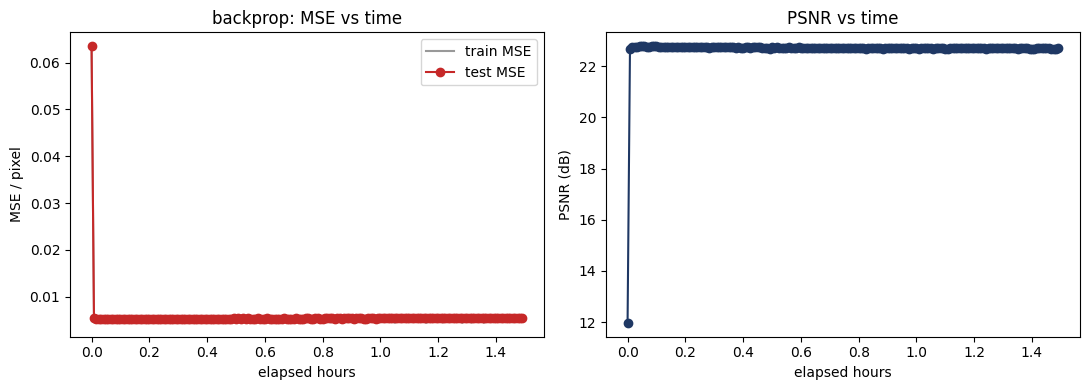

[h=1.49] step=2,023,774 test_mse=0.00537 psnr=22.70 ssim=0.794
[backprop] h=1.50 step=2,034,841 train=0.0053 test_mse=0.00537 psnr=22.70 ssim=0.794
[backprop] h=1.52 step=2,057,643 train=0.0048 test_mse=0.00539 psnr=22.69 ssim=0.795
[backprop] h=1.53 step=2,080,602 train=0.0054 test_mse=0.00537 psnr=22.70 ssim=0.795
[backprop] h=1.55 step=2,103,496 train=0.0045 test_mse=0.00538 psnr=22.69 ssim=0.794
[backprop] h=1.57 step=2,126,268 train=0.0053 test_mse=0.00537 psnr=22.70 ssim=0.795
[backprop] h=1.58 step=2,149,039 train=0.0047 test_mse=0.00541 psnr=22.67 ssim=0.795
[backprop] h=1.60 step=2,171,827 train=0.0048 test_mse=0.00539 psnr=22.69 ssim=0.794
[backprop] h=1.62 step=2,194,238 train=0.0047 test_mse=0.00537 psnr=22.70 ssim=0.794
[backprop] h=1.63 step=2,217,212 train=0.0050 test_mse=0.00539 psnr=22.69 ssim=0.795
[backprop] h=1.65 step=2,240,020 train=0.0050 test_mse=0.00538 psnr=22.70 ssim=0.795
[backprop] h=1.67 step=2,262,561 train=0.0047 test_mse=0.00542 psnr=22.66 ssim=0.793
[b

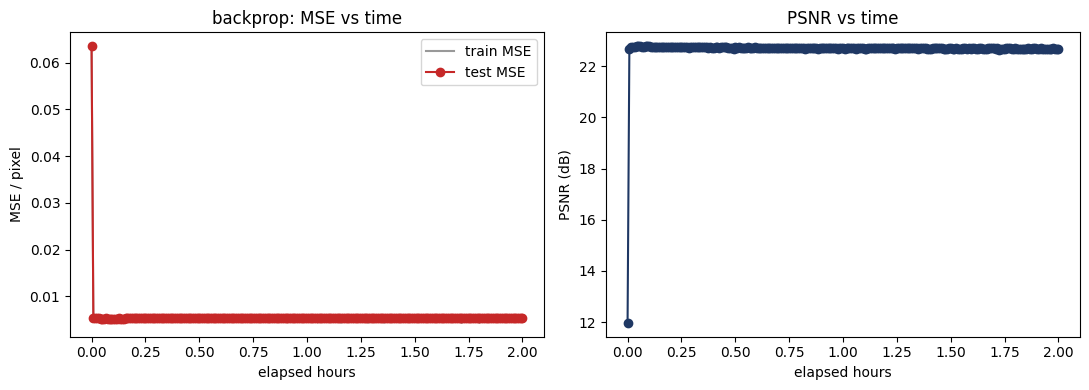

[h=2.00] step=2,711,676 test_mse=0.00539 psnr=22.68 ssim=0.794
wrote /content/drive/MyDrive/Section7_r1_cifar10_denoiser/results/backprop.json
DONE backprop: 2,711,676 steps, 2.00h, PSNR 22.68dB SSIM 0.794, best MSE 0.00527


In [11]:
def write_results(step, elapsed, logs):
    mse = [l[4] for l in logs]; psnr = [l[5] for l in logs]; ssim = [l[6] for l in logs]
    summary = dict(initial_mse=logs[0][4], final_mse=logs[-1][4], best_mse=min(mse),
                   final_psnr=logs[-1][5], best_psnr=max(psnr),
                   final_ssim=logs[-1][6], best_ssim=max(ssim))
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, samples=step*BATCH, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], samples=[l[2] for l in logs],
                          train_mse=[l[3] for l in logs], test_mse=mse, test_psnr=psnr, test_ssim=ssim),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        m0, p0, s0 = eval_metrics(); logs.append((elapsed0, step, 0, m0, m0, p0, s0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            mse, psnr, ssim = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, mse, psnr, ssim)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.4f} test_mse={L[4]:.5f} psnr={L[5]:.2f} ssim={L[6]:.3f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    mse, psnr, ssim = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, mse, psnr, ssim))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, PSNR {psnr:.2f}dB SSIM {ssim:.3f}, best MSE {min(l[4] for l in logs):.5f}')

run()

## How to run
- `SMOKE=True` first, then `False` → Runtime → Run all.
- Equal wall-clock; heartbeat ~60 s; disconnect-safe (auto-resume); writes `results/<method>.json`. Loss = MSE, metrics = PSNR (dB) + SSIM. CIFAR reconstructions from a 1M autoencoder are blurry — the signal is method ordering + the cos sweep, not SOTA quality. Compare in `CIFAR-10 Denoiser - 06_compare_results.ipynb`.